>>> ЗАВАНТАЖЕННЯ МОДЕЛЕЙ...
>>> ЗНАЙДЕНО ФАЙЛІВ: 699
>>> ПОЧАТОК ТЕСТУВАННЯ...


 23%|██████████████████▍                                                              | 159/699 [00:17<01:00,  8.86it/s]

WARNING ⚠️ NMS time limit 2.050s exceeded


100%|█████████████████████████████████████████████████████████████████████████████████| 699/699 [01:30<00:00,  7.72it/s]


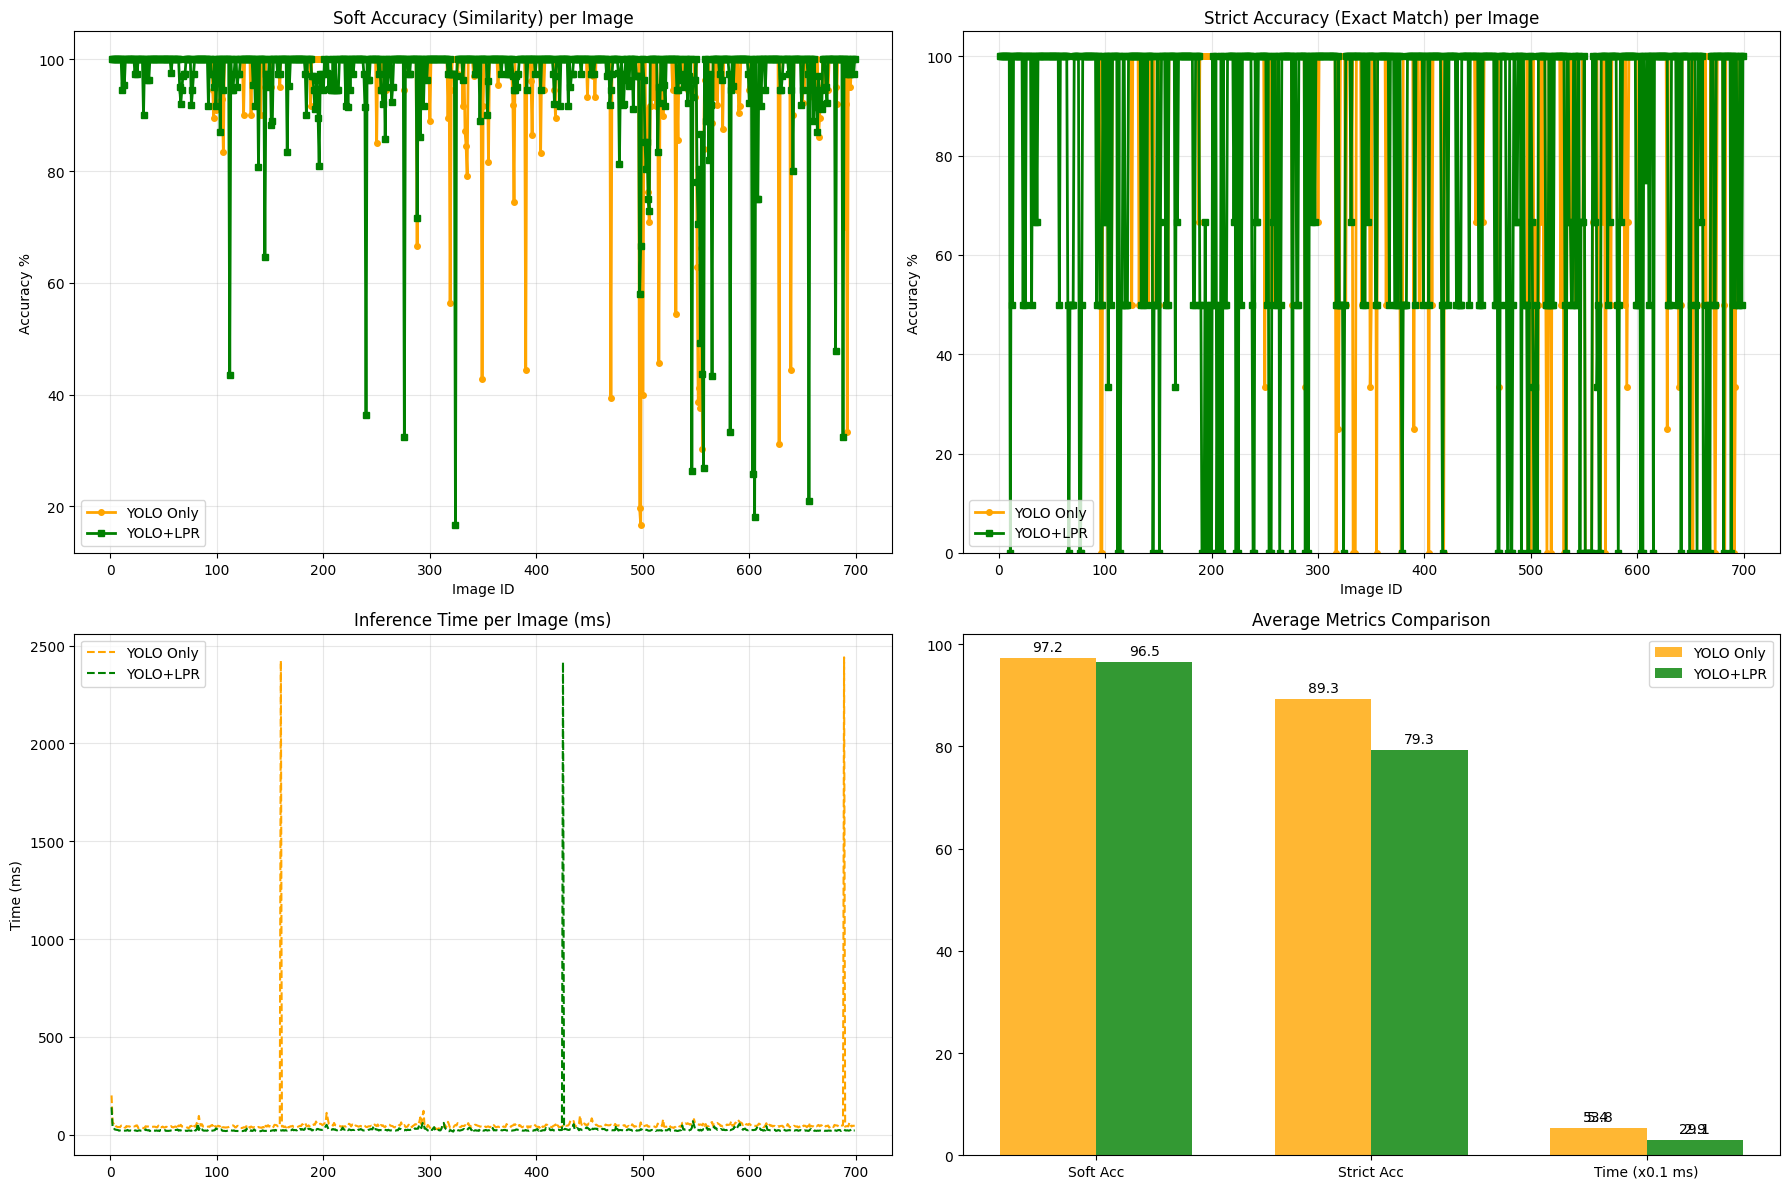

>>> ГОТОВО! Перевірте папку: benchmark_results_ultimate


In [6]:
import os
import cv2
import json
import time
import math
import csv
import numpy as np
import torch
import matplotlib.pyplot as plt
from glob import glob
from ultralytics import YOLO
import sys
from tqdm import tqdm
from difflib import SequenceMatcher

# ==========================================
# КОНФІГУРАЦІЯ
# ==========================================
IMAGES_DIR = 'final_dataset_yoloOnly/images/test'
# LABELS_DIR = 'final_dataset_yoloOnly/labels/test'
LABELS_DIR = 'unity/labels' # Змінив на unity, бо там json-и. Перевір цей шлях!

RESULTS_DIR = 'benchmark_results_ultimate'

# Моделі
YOLO_ONLY_WEIGHTS = "runs/detect/yolo_only/weights/best.pt"
YOLO_ZONE_WEIGHTS = "yolo_project/runs/exp_numbers/weights/best.pt"
LPRNET_WEIGHTS = "weights/lprnet_best.pth"
LPRNET_REPO_PATH = 'LPRNet_Pytorch'

# Параметри сортування
MAX_ANGLE_DEG = 25.0
MAX_GAP_RATIO = 2.5
DUPLICATE_DIST_THRESH = 5.0

# Константи
CHARS = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '-', '.']
YOLO_NAMES = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4',
    5: '5', 6: '6', 7: '7', 8: '8', 9: '9',
    10: 'minus', 11: 'point', 12: 'tag'
}
CHAR_MAP = {
    '0': '0', '1': '1', '2': '2', '3': '3', '4': '4',
    '5': '5', '6': '6', '7': '7', '8': '8', '9': '9',
    'minus': '-', 'point': '.', 'tag': ''
}

os.makedirs(RESULTS_DIR, exist_ok=True)

if LPRNET_REPO_PATH not in sys.path:
    sys.path.append(LPRNET_REPO_PATH)
try:
    from model.LPRNet import LPRNet
except ImportError:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. МЕТРИКИ (НОВА ЛОГІКА)
# ==========================================
def similarity_score(a, b):
    return SequenceMatcher(None, a, b).ratio()

def calc_metrics(gt_list, pred_list):
    """
    Повертає (soft_acc, hard_acc).
    Обробляє випадок порожнього GT як перемогу моделі, якщо вона щось знайшла.
    """
    # 1. Спеціальний кейс: GT порожній
    if not gt_list:
        if not pred_list:
            # GT порожній, Модель нічого не знайшла -> Ідеально
            return 100.0, 100.0
        else:
            # GT порожній, Модель знайшла щось -> Вважаємо це 100% (User Request)
            # (Припускаємо, що розмітка пропустила цифри)
            return 100.0, 100.0

    # 2. Якщо GT є, а модель нічого не знайшла -> 0
    if not pred_list:
        return 0.0, 0.0

    # 3. Стандартний розрахунок
    soft_total = 0.0
    hard_matches = 0
    limit = max(len(gt_list), len(pred_list))

    for i in range(limit):
        gt_item = gt_list[i] if i < len(gt_list) else ""
        pred_item = pred_list[i] if i < len(pred_list) else ""

        # Soft (Levenshtein)
        soft_total += similarity_score(gt_item, pred_item)

        # Hard (Strict)
        if gt_item == pred_item:
            hard_matches += 1

    soft_acc = (soft_total / limit) * 100
    hard_acc = (hard_matches / limit) * 100 # Тут ділимо на limit (макс довжину), щоб штрафувати за зайві/пропущені

    return soft_acc, hard_acc

# ==========================================
# 2. СОРТУВАННЯ (ЗБЕРЕЖЕНО ПОПЕРЕДНЄ)
# ==========================================
def organize_lpr_zones(boxes):
    # (Той самий код сортування зон, що був у попередній версії)
    if not boxes: return []
    zones = [{'box': b, 'cx': (b[0]+b[2])/2, 'cy': (b[1]+b[3])/2, 'h': b[3]-b[1]} for b in boxes]
    zones.sort(key=lambda z: z['cy'])
    rows = []
    if zones:
        curr_row = [zones[0]]
        for i in range(1, len(zones)):
            curr = zones[i]
            prev = curr_row[-1]
            if abs(curr['cy'] - prev['cy']) < (prev['h'] * 0.6):
                curr_row.append(curr)
            else:
                rows.append(curr_row)
                curr_row = [curr]
        rows.append(curr_row)
    final = []
    for row in rows:
        row.sort(key=lambda z: z['cx'])
        for item in row: final.append(item['box'])
    return final

def organize_text_lines_chars(chars):
    # (Той самий код для YOLO Only)
    if not chars: return []
    chars.sort(key=lambda c: c['conf'], reverse=True)
    valid = []
    for c in chars:
        is_dup = False
        for v in valid:
            if math.hypot(c['cx']-v['cx'], c['cy']-v['cy']) < DUPLICATE_DIST_THRESH:
                is_dup = True; break
        if not is_dup: valid.append(c)
    chars = sorted(valid, key=lambda c: c['cx'])
    lines = []
    for char in chars:
        best_line = None
        min_dist = float('inf')
        for line in lines:
            last = line[-1]
            dx = char['cx'] - last['cx']; dy = char['cy'] - last['cy']
            if dx <= 0: continue
            dist = math.hypot(dx, dy); angle = math.degrees(math.atan2(dy, dx))
            avg_s = (last['w']+char['w']+last['h']+char['h'])/4
            if abs(angle)>MAX_ANGLE_DEG or dist > avg_s*MAX_GAP_RATIO*2: continue
            if dist < min_dist: min_dist = dist; best_line = line
        if best_line: best_line.append(char)
        else: lines.append([char])
    lines.sort(key=lambda l: sum(c['cy'] for c in l)/len(l))
    final = []
    for line in lines:
        s = ""; prev_x = line[0]['x'] + line[0]['w']
        for i, c in enumerate(line):
            if i>0:
                gap = c['x'] - prev_x; avg_w = (c['w']+line[i-1]['w'])/2
                if gap > avg_w * 0.8:
                    if s.strip(): final.append(s)
                    s = ""
            s += c['char']; prev_x = c['x'] + c['w']
        if s.strip(): final.append(s)
    return final

# ==========================================
# 3. ФУНКЦІЇ ЗАПУСКУ (INFERENCE)
# ==========================================
def run_yolo_only(model, img):
    t0 = time.time()
    res = model(img, conf=0.25, verbose=False)[0]
    chars = []
    for box in res.boxes:
        cls = int(box.cls[0]); lbl = YOLO_NAMES.get(cls, '?'); sym = CHAR_MAP.get(lbl, '')
        if not sym: continue
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        chars.append({'char':sym, 'cx':(x1+x2)/2, 'cy':(y1+y2)/2, 'x':x1,'y':y1,'w':x2-x1,'h':y2-y1, 'conf':float(box.conf[0])})
    text = organize_text_lines_chars(chars)
    return text, (time.time()-t0)*1000, res

def decode_lpr(preds):
    preds = preds.cpu().detach().numpy(); labels = np.argmax(preds, axis=1); decoded = []
    for i in range(labels.shape[0]):
        line = labels[i,:]; res = []; pre = -1
        for c in line:
            if c!=pre and c!=len(CHARS): res.append(CHARS[c])
            pre=c
        decoded.append("".join(res))
    return decoded[0]

def run_lpr(yolo_zone, lpr, img):
    t0 = time.time()
    res = yolo_zone(img, verbose=False)[0]
    boxes = organize_lpr_zones(res.boxes.xyxy.cpu().numpy().astype(int).tolist())
    texts = []; valid_boxes = []
    for b in boxes:
        x1,y1,x2,y2 = b; x1,y1 = max(0,x1), max(0,y1); x2,y2 = min(img.shape[1],x2), min(img.shape[0],y2)
        crop = img[y1:y2, x1:x2]
        if crop.size==0: continue
        blob = cv2.resize(crop, (94,24)).astype('float32'); blob -= 127.5; blob *= 0.0078125
        blob = np.transpose(blob, (2,0,1)); blob = torch.from_numpy(blob).unsqueeze(0).to(device)
        with torch.no_grad():
            texts.append(decode_lpr(lpr(blob)))
            valid_boxes.append(b)
    return texts, (time.time()-t0)*1000, valid_boxes

# ==========================================
# 4. ГОЛОВНИЙ СКРИПТ
# ==========================================
def get_gt(path):
    name = os.path.basename(path).replace('.jpg','').replace('.png','')
    json_p = os.path.join(LABELS_DIR, name+'.json')
    nums = []
    if os.path.exists(json_p):
        try:
            with open(json_p) as f:
                data = json.load(f)
                items = data if isinstance(data, list) else [data]
                for item in items:
                    if 'data_raw' in item:
                        for g in item['data_raw']:
                            for t in g:
                                if any(c.isdigit() for c in t): nums.append(t)
        except: pass
    return nums

def plot_charts(data, output_dir):
    """Будує професійні графіки з авто-зумом"""
    ids = range(1, len(data) + 1)

    y_soft = [d['y_soft'] for d in data]; y_hard = [d['y_hard'] for d in data]; y_time = [d['y_time'] for d in data]
    l_soft = [d['l_soft'] for d in data]; l_hard = [d['l_hard'] for d in data]; l_time = [d['l_time'] for d in data]

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 2)

    # helper zoom
    def set_dynamic_lim(ax, d1, d2, margin=5):
        comb = d1 + d2
        mn, mx = min(comb), max(comb)
        ax.set_ylim(max(0, mn - margin), min(105, mx + margin))

    # 1. SOFT ACCURACY (LINE)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(ids, y_soft, label='YOLO Only', color='orange', linewidth=2, marker='o', markersize=4)
    ax1.plot(ids, l_soft, label='YOLO+LPR', color='green', linewidth=2, marker='s', markersize=4)
    ax1.set_title("Soft Accuracy (Similarity) per Image")
    ax1.set_xlabel("Image ID")
    ax1.set_ylabel("Accuracy %")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    set_dynamic_lim(ax1, y_soft, l_soft)

    # 2. STRICT ACCURACY (LINE)
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(ids, y_hard, label='YOLO Only', color='orange', linewidth=2, marker='o', markersize=4)
    ax2.plot(ids, l_hard, label='YOLO+LPR', color='green', linewidth=2, marker='s', markersize=4)
    ax2.set_title("Strict Accuracy (Exact Match) per Image")
    ax2.set_xlabel("Image ID")
    ax2.set_ylabel("Accuracy %")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    set_dynamic_lim(ax2, y_hard, l_hard)

    # 3. SPEED (LINE)
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(ids, y_time, label='YOLO Only', color='orange', linestyle='--')
    ax3.plot(ids, l_time, label='YOLO+LPR', color='green', linestyle='--')
    ax3.set_title("Inference Time per Image (ms)")
    ax3.set_ylabel("Time (ms)")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. AVERAGE COMPARISON (BAR)
    ax4 = fig.add_subplot(gs[1, 1])
    labels = ['Soft Acc', 'Strict Acc', 'Time (x0.1 ms)']
    y_means = [np.mean(y_soft), np.mean(y_hard), np.mean(y_time)*0.1] # Scale time for visualization
    l_means = [np.mean(l_soft), np.mean(l_hard), np.mean(l_time)*0.1]

    x = np.arange(len(labels))
    width = 0.35

    rects1 = ax4.bar(x - width/2, y_means, width, label='YOLO Only', color='orange', alpha=0.8)
    rects2 = ax4.bar(x + width/2, l_means, width, label='YOLO+LPR', color='green', alpha=0.8)

    ax4.set_title('Average Metrics Comparison')
    ax4.set_xticks(x)
    ax4.set_xticklabels(labels)
    ax4.legend()

    def autolabel(rects, is_time=False):
        for rect in rects:
            height = rect.get_height()
            val = height * 10 if is_time else height
            txt = f"{val:.1f}"
            ax4.annotate(txt, xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    autolabel(rects1, is_time=False); autolabel(rects1[2:], is_time=True)
    autolabel(rects2, is_time=False); autolabel(rects2[2:], is_time=True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'ULTIMATE_CHARTS.png'), dpi=300)
    plt.show()

def main():
    print(">>> ЗАВАНТАЖЕННЯ МОДЕЛЕЙ...")
    y_only = YOLO(YOLO_ONLY_WEIGHTS)
    y_zone = YOLO(YOLO_ZONE_WEIGHTS)
    lpr = LPRNet(lpr_max_len=18, phase=False, class_num=13, dropout_rate=0).to(device)
    lpr.load_state_dict(torch.load(LPRNET_WEIGHTS, map_location=device))
    lpr.eval()

    files = glob(os.path.join(IMAGES_DIR, '*.jpg')) + glob(os.path.join(IMAGES_DIR, '*.png'))
    print(f">>> ЗНАЙДЕНО ФАЙЛІВ: {len(files)}")

    dataset_data = []

    print(">>> ПОЧАТОК ТЕСТУВАННЯ...")
    for f in tqdm(files):
        img = cv2.imread(f)
        if img is None: continue
        gt = get_gt(f)

        # 1. Inference
        y_txt, y_time, y_res = run_yolo_only(y_only, img)
        l_txt, l_time, l_boxes = run_lpr(y_zone, lpr, img)

        # 2. Metrics
        y_soft, y_hard = calc_metrics(gt, y_txt)
        l_soft, l_hard = calc_metrics(gt, l_txt)

        dataset_data.append({
            'file': os.path.basename(f),
            'y_soft': y_soft, 'y_hard': y_hard, 'y_time': y_time,
            'l_soft': l_soft, 'l_hard': l_hard, 'l_time': l_time
        })

        # 3. Visualization
        h, w = img.shape[:2]
        vis = np.zeros((h + 120, w * 2, 3), dtype=np.uint8) # Canvas
        vis[:] = (240, 240, 240)

        # Embed images
        vis[120:120+h, 0:w] = img
        vis[120:120+h, w:2*w] = img

        # Draw Results YOLO
        cv2.putText(vis, "YOLO ONLY", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,140,255), 2)
        cv2.putText(vis, f"Soft: {y_soft:.0f}% | Hard: {y_hard:.0f}%", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)
        cv2.putText(vis, f"GT: {gt}", (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (50,50,50), 1)
        for b in y_res.boxes: # Draw boxes
            x1,y1,x2,y2 = map(int, b.xyxy[0])
            cv2.rectangle(vis, (x1, y1+120), (x2, y2+120), (0,140,255), 1)
        # Draw Pred Text YOLO
        cv2.putText(vis, f"Pred: {y_txt}", (10, h+110), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,140,255), 2)

        # Draw Results LPR
        cv2.putText(vis, "YOLO + LPRNet", (w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,200,0), 2)
        cv2.putText(vis, f"Soft: {l_soft:.0f}% | Hard: {l_hard:.0f}%", (w+10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)
        cv2.putText(vis, f"GT: {gt}", (w+10, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (50,50,50), 1)
        for i, b in enumerate(l_boxes):
            x1,y1,x2,y2 = b
            cv2.rectangle(vis, (x1+w, y1+120), (x2+w, y2+120), (0,200,0), 2)
            if i < len(l_txt):
                cv2.putText(vis, l_txt[i], (x1+w, y1+115), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,200,0), 2)
        # Draw Pred Text LPR
        cv2.putText(vis, f"Pred: {l_txt}", (w+10, h+110), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,200,0), 2)

        cv2.imwrite(os.path.join(RESULTS_DIR, os.path.basename(f)), vis)

    # 4. Save CSV
    csv_path = os.path.join(RESULTS_DIR, 'benchmark_data.csv')
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=dataset_data[0].keys())
        writer.writeheader()
        writer.writerows(dataset_data)

    # 5. Plot Charts
    plot_charts(dataset_data, RESULTS_DIR)
    print(f">>> ГОТОВО! Перевірте папку: {RESULTS_DIR}")

if __name__ == "__main__":
    main()